<a href="https://colab.research.google.com/github/AchyuthaAshish/AI-ML-Projects/blob/main/02_Sentiment_Analysis/Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip -q install pandas numpy scikit-learn matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [3]:
import os
import urllib.request
import tarfile

dataset_url = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"

dataset_file = "aclImdb_v1.tar.gz"

print("Downloading IMDb dataset...")

urllib.request.urlretrieve(dataset_url, dataset_file)

print("Extracting dataset...")

with tarfile.open(dataset_file, "r:gz") as tar:
    tar.extractall(".")

print("✅ IMDb dataset downloaded and extracted!")

Extracting dataset...


/tmp/ipykernel_832/1071656605.py:16: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(".")


✅ IMDb dataset downloaded and extracted!


In [4]:
import glob

reviews = []
sentiments = []

dataset_path = "aclImdb"

for sentiment in ["pos", "neg"]:

    folder = os.path.join(dataset_path, "train", sentiment)

    files = glob.glob(os.path.join(folder, "*.txt"))

    for file_path in files:

        try:
            with open(file_path, "r", encoding="utf-8") as f:
                review = f.read()

            if review.strip():
                reviews.append(review)
                sentiments.append(sentiment)

        except Exception:
            continue


df = pd.DataFrame({
    "review": reviews,
    "sentiment": sentiments
})

print("✅ Reviews loaded successfully!")
print("Total reviews:", len(df))

print("\nSentiment distribution:")
print(df["sentiment"].value_counts())

print("\nDataset shape:", df.shape)

✅ Reviews loaded successfully!
Total reviews: 25000

Sentiment distribution:
sentiment
pos    12500
neg    12500
Name: count, dtype: int64

Dataset shape: (25000, 2)


In [5]:
print("Sample reviews:\n")

for i in range(5):
    print(f"\nReview {i + 1}")
    print("-" * 70)
    print(df.iloc[i]["review"][:500])
    print("Sentiment:", df.iloc[i]["sentiment"])

Sample reviews:


Review 1
----------------------------------------------------------------------
I can safely admit (as an IMDb geek) that 'Phantom Lady' will never crack into my film noir top twenty. It may not even sneak into the top fifty. But rather than discredit the film for not being as good as so many other classics of the film noir genre, it should be noted that 'Phantom Lady' has enough strong and lasting images in it to make it a worthwhile viewing. All that is required from the viewer is the ability to get beyond the dreadfully slow beginning.<br /><br />The film doesn't get coo
Sentiment: pos

Review 2
----------------------------------------------------------------------
Broadway and film actor-turned-director John Cassavetes (from Rosemary's Baby)creates a masterpiece with this 1977 film. It stars Gena Rowlands, John Cassavetes himself, Ben Gazzara, Joan Blondell, Paul Stewart, Zohra Lampert, Laura Johnson and there is a cameo by Peter Falk. The premise of the film: An 

In [6]:
df.dropna(inplace=True)

df.drop_duplicates(subset="review", inplace=True)

df.reset_index(drop=True, inplace=True)

print("Dataset after cleaning:", df.shape)

print("\nSentiment distribution:")
print(df["sentiment"].value_counts())

Dataset after cleaning: (24904, 2)

Sentiment distribution:
sentiment
pos    12472
neg    12432
Name: count, dtype: int64


In [7]:
df["target"] = df["sentiment"].map({
    "neg": 0,
    "pos": 1
})

print("\nTarget distribution:")
print(df["target"].value_counts())


Target distribution:
target
1    12472
0    12432
Name: count, dtype: int64


In [8]:
X = df["review"]
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training reviews:", len(X_train))
print("Testing reviews :", len(X_test))

Training reviews: 19923
Testing reviews : 4981


In [9]:
tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    max_features=50000,
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF training shape:", X_train_tfidf.shape)
print("TF-IDF testing shape :", X_test_tfidf.shape)

TF-IDF training shape: (19923, 50000)
TF-IDF testing shape : (4981, 50000)


In [10]:
model = LogisticRegression(
    max_iter=1000
)

model.fit(X_train_tfidf, y_train)

print("✅ Sentiment classification model trained successfully!")

✅ Sentiment classification model trained successfully!


In [11]:
y_pred = model.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=" * 60)
print("          SENTIMENT ANALYSIS RESULTS")
print("=" * 60)

print(f"Accuracy  : {accuracy * 100:.2f}%")
print(f"Precision : {precision * 100:.2f}%")
print(f"Recall    : {recall * 100:.2f}%")
print(f"F1 Score  : {f1 * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["NEGATIVE", "POSITIVE"]
))

          SENTIMENT ANALYSIS RESULTS
Accuracy  : 88.18%
Precision : 86.49%
Recall    : 90.54%
F1 Score  : 88.47%

Classification Report:
              precision    recall  f1-score   support

    NEGATIVE       0.90      0.86      0.88      2486
    POSITIVE       0.86      0.91      0.88      2495

    accuracy                           0.88      4981
   macro avg       0.88      0.88      0.88      4981
weighted avg       0.88      0.88      0.88      4981



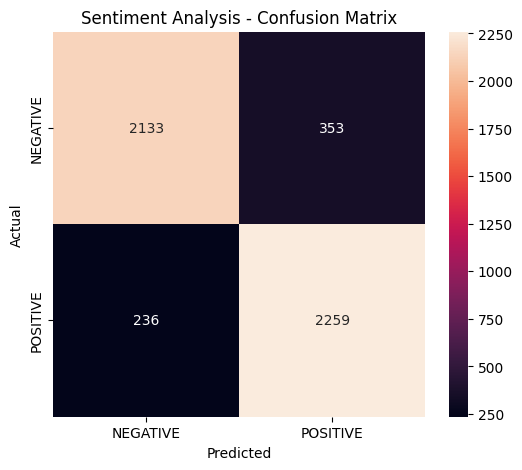

In [12]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["NEGATIVE", "POSITIVE"],
    yticklabels=["NEGATIVE", "POSITIVE"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Sentiment Analysis - Confusion Matrix")

plt.show()

In [13]:
def predict_sentiment(text):

    text_tfidf = tfidf.transform([text])

    prediction = model.predict(text_tfidf)[0]

    probabilities = model.predict_proba(text_tfidf)[0]

    negative_probability = probabilities[0]
    positive_probability = probabilities[1]

    if prediction == 1:
        sentiment = "POSITIVE"
    else:
        sentiment = "NEGATIVE"

    return sentiment, negative_probability, positive_probability

In [17]:
print("=" * 70)
print("                  SENTIMENT ANALYZER")
print("=" * 70)

text = input("\nEnter a review or sentence: ")

sentiment, negative_probability, positive_probability = predict_sentiment(text)

print("\n" + "=" * 70)
print("                         RESULT")
print("=" * 70)

print("Text               :", text)
print("Sentiment          :", sentiment)
print("Negative Probability:", f"{negative_probability * 100:.2f}%")
print("Positive Probability:", f"{positive_probability * 100:.2f}%")

if sentiment == "POSITIVE":
    print("\n😊 This text expresses a positive sentiment.")
else:
    print("\n😞 This text expresses a negative sentiment.")

                  SENTIMENT ANALYZER

Enter a review or sentence: what an fantastic movie

                         RESULT
Text               : what an fantastic movie
Sentiment          : POSITIVE
Negative Probability: 15.95%
Positive Probability: 84.05%

😊 This text expresses a positive sentiment.


In [18]:
import joblib

joblib.dump(model, "sentiment_classifier.pkl")
joblib.dump(tfidf, "sentiment_tfidf_vectorizer.pkl")

print("✅ Sentiment model and TF-IDF vectorizer saved successfully!")

✅ Sentiment model and TF-IDF vectorizer saved successfully!
